# TP7: The Tracer

**IFT3395/IFT6390 — Foundations of Machine Learning**

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/pierrelux/mlbook/blob/main/exercises/tp7_traceur.ipynb)

This notebook accompanies [Chapter 7: Neural Networks](https://pierrelux.github.io/mlbook/ch7_neural_networks), section "The Tracer". You will implement a reverse-mode automatic differentiation engine by exploring two interception mechanisms: Python operator overloading and the namespace approach (as in autograd/JAX).

## Objectives

By the end of this practical exercise, you will be able to:
- Explain the role of the tracer in a reverse-mode AD system
- Implement a scalar tracer by overloading `float` operators
- Build a `grad` function analogous to `jax.grad`
- Verify gradients by analytical comparison and finite differences
- Extract a computation graph from the recording tape
- Compare operator overloading and the namespace approach for operation interception

Prerequisites: Ch7, sections "Automatic Differentiation" and "The Tracer".

---

## Part 0: Setup

In [41]:
import math
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['font.size'] = 12
print("Setup complete!")

Setup complete!


---
## Part 1: Why automate graph construction?

The previous notebook ([Automatic Differentiation with NetworkX](https://pierrelux.github.io/mlbook/exercises/autodiff_graphe)) showed how to manually construct a computation graph with NetworkX, then traverse it in reverse mode. This approach is educational, but it has three shortcomings:

1. **Redundancy**: each operation is written twice (once in the graph, once to evaluate the function)
2. **Fragility**: any modification to the function requires rebuilding the graph by hand
3. **Separation**: the computation description and its execution live in two different places

The idea of the **tracer** solves all three problems at once: we wrap each number in an object that overloads Python operators (`+`, `*`, etc.) and automatically records operations on a **tape**. After execution, the tape contains exactly the computation graph — built automatically.

### VJP Rules Library

Each primitive operation has a VJP (*vector-Jacobian product*) rule that computes the input cotangents from the output cotangent. The common signature is `vjp(residuals, cotangent_output) → input_cotangents`:

In [42]:
# ---- VJP Rules Library ----
# Common signature: vjp(residuals, output_cotangent) → input_cotangents

def add_vjp(_, g):
    return (g, g)                        # ∂(a+b)/∂a = 1, ∂(a+b)/∂b = 1

def mul_vjp(res, g):
    a, b = res
    return (b * g, a * g)                # ∂(a·b)/∂a = b, ∂(a·b)/∂b = a

def sin_vjp(res, g):
    (a,) = res
    return (math.cos(a) * g,)            # ∂sin(a)/∂a = cos(a)

def exp_vjp(res, g):
    (a,) = res
    return (math.exp(a) * g,)            # ∂exp(a)/∂a = exp(a)

def neg_vjp(res, g):
    (a,) = res
    return (-g,)                         # ∂(-a)/∂a = -1

---
## Part 2: The Tracer — `Var` class

The tracer is an object that masquerades as a number. It encapsulates:
- **`data`**: the numerical value (a `float`)
- **`id`**: a unique identifier (auto-incremented integer)

At each arithmetic operation, the tracer:
1. Computes the numerical result (forward pass)
2. Records an entry on the global `_tape`: the VJP rule, the residuals, the input identifiers, and the output identifier
3. Returns a new `Var` containing the result

The `_record` method (given below) performs steps 2 and 3. The `__add__` operator is given as an example.

In [43]:
_tape = []      # global tape: [(vjp_fn, residuals, input_ids, output_id)]
_n_vars = 0     # identifier counter

class Var:
    """Scalar tracer: wraps a float and a unique identifier."""

    def __init__(self, data):
        global _n_vars
        self.data = float(data)
        self.id = _n_vars
        _n_vars += 1

    def _record(self, vjp_fn, res, inputs, out_data):
        """Records an operation on the tape and returns a new Var."""
        out = Var(out_data)
        _tape.append((vjp_fn, res, [v.id for v in inputs], out.id))
        return out

    # --- Exemple: addition ---
    def __add__(self, other):
        other = other if isinstance(other, Var) else Var(other)
        return self._record(
            add_vjp, 
            (self.data, other.data),
            [self, other], 
            self.data + other.data)

    def __radd__(self, other): return self.__add__(other)

    # ============================================
    # Exercise 1 ★★: Implement the missing operators
    #
    # Following the pattern of __add__ above, implement:
    #   __mul__(self, other)  — multiplication
    #   __rmul__(self, other) — multiplication (left operand not a Var)
    #   sin(self)             — sinus
    #   exp(self)             — exponentielle
    #   __neg__(self)         — unary negation
    #
    # Each method calls self._record with the correct
    # VJP rule, the correct residuals, and the correct numerical result.
    # ============================================

    def __mul__(self, other):
        other = other if isinstance(other, Var) else Var(other)
        return self._record(
            mul_vjp, 
            (self.data, other.data),
            [self, other], 
            self.data * other.data)

    def __rmul__(self, other):
        return self.__mul__(other)

    def sin(self):
        return self._record(sin_vjp, (self.data,), [self], math.sin(self.data))

    def exp(self):
        return self._record(exp_vjp, (self.data,), [self], math.exp(self.data))

    def __neg__(self):
        return self._record(neg_vjp, (self.data,), [self], -self.data)

<details>
<summary><b>Solution Exercise 1</b> (click to show)</summary>

```python
def __mul__(self, other):
    other = other if isinstance(other, Var) else Var(other)
    return self._record(mul_vjp, (self.data, other.data),
                        [self, other], self.data * other.data)

def __rmul__(self, other): return self.__mul__(other)

def sin(self):
    return self._record(sin_vjp, (self.data,),
                        [self], math.sin(self.data))

def exp(self):
    return self._record(exp_vjp, (self.data,),
                        [self], math.exp(self.data))

def __neg__(self):
    return self._record(neg_vjp, (self.data,),
                        [self], -self.data)
```
</details>

In [44]:
# Verification: trace f(x,y) = sin(xy) + exp(x)
_tape, _n_vars = [], 0
x = Var(0.5)
y = Var(3.0)
result = (x * y).sin() + x.exp()

print(f"f(0.5, 3.0) = {result.data:.6f}")
print(f"Verification: sin(0.5*3.0) + exp(0.5) = {math.sin(1.5) + math.exp(0.5):.6f}")
print(f"\nTape contents ({len(_tape)} entries):")
for vjp_fn, res, in_ids, out_id in _tape:
    op = vjp_fn.__name__.replace('_vjp', '')
    print(f"  {op}: entries={in_ids} → output={out_id}, residuals={res}")

f(0.5, 3.0) = 2.646216
Verification: sin(0.5*3.0) + exp(0.5) = 2.646216

Tape contents (4 entries):
  mul: entries=[0, 1] → output=2, residuals=(0.5, 3.0)
  sin: entries=[2] → output=3, residuals=(1.5,)
  exp: entries=[0] → output=4, residuals=(0.5,)
  add: entries=[3, 4] → output=5, residuals=(0.9974949866040544, 1.6487212707001282)


---
## Part 3: The `grad` function

The `grad` function is a **higher-order operator**: it takes a function `f` and returns a new function that computes the gradient of `f`. It is the analogue of `jax.grad`.

It works in three steps:
1. **Reset** the tape and the counter
2. **Forward pass**: wrap the inputs in `Var` objects, call `f` — the tape fills up automatically
3. **Backward pass**: traverse the tape in reverse order, propagate the cotangents by accumulation

In [45]:
def grad(f):
    """Returns a function that computes the gradient of f."""
    def grad_fn(*args):
        global _tape, _n_vars
        _tape, _n_vars = [], 0               # reset the tape

        # Forward pass: trace the execution
        traced = [Var(a) for a in args]
        result = f(*traced)

        # Backward pass: propagate the cotangents
        adjoints = [0.0] * _n_vars
        adjoints[result.id] = 1.0            # ∂f/∂f = 1

        # ============================================
        # Exercise 2 ★★: Complete the backward pass
        #
        # Parcourez the tape en ordre inverse avec reversed(_tape).
        # Pour chaque entry (vjp_fn, res, in_ids, out_id):
        #   1. Get the output cotangent: adjoints[out_id]
        #   2. Appelez vjp_fn(res, cotangent) pour obtenir les cotangents
        #   3. Accumulez: adjoints[idx] += ct pour chaque (idx, ct)
        # ============================================

        for vjp_fn, res, in_ids, out_id in reversed(_tape):
            cotangent = adjoints[out_id]
            input_cotangents = vjp_fn(res, cotangent)
            for idx, ct in zip(in_ids, input_cotangents):
                adjoints[idx] += ct
        

        return tuple(adjoints[v.id] for v in traced)
    return grad_fn

<details>
<summary><b>Solution Exercise 2</b> (click to show)</summary>

```python
for vjp_fn, res, in_ids, out_id in reversed(_tape):
    cotangents = vjp_fn(res, adjoints[out_id])
    for idx, ct in zip(in_ids, cotangents):
        adjoints[idx] += ct
```
</details>

---
## Part 4: Verification

Let's test the tracer on the same functions as the NetworkX notebook, with the same numerical values, for direct comparison.

### Function $f(x,y) = \sin(xy) + e^x$

Analytical gradients:
$$\frac{\partial f}{\partial x} = y\cos(xy) + e^x, \qquad \frac{\partial f}{\partial y} = x\cos(xy)$$

In [46]:
def f(x, y):
    return (x * y).sin() + x.exp()

x_val, y_val = 0.5, 3.0
df_dx, df_dy = grad(f)(x_val, y_val)

# Analytical gradients
df_dx_exact = y_val * math.cos(x_val * y_val) + math.exp(x_val)
df_dy_exact = x_val * math.cos(x_val * y_val)

# Finite differences
def f_np(x, y):
    return np.sin(x * y) + np.exp(x)

eps = 1e-7
df_dx_num = (f_np(x_val + eps, y_val) - f_np(x_val - eps, y_val)) / (2 * eps)
df_dy_num = (f_np(x_val, y_val + eps) - f_np(x_val, y_val - eps)) / (2 * eps)

print("--- f(x,y) = sin(xy) + exp(x) ---")
print(f"f({x_val}, {y_val}) = {f_np(x_val, y_val):.6f}")
print(f"\n{'Method':<25} {'∂f/∂x':>12} {'∂f/∂y':>12}")
print(f"{'-'*25} {'-'*12} {'-'*12}")
print(f"{'Tracer':<25} {df_dx:>12.6f} {df_dy:>12.6f}")
print(f"{'Analytical':<25} {df_dx_exact:>12.6f} {df_dy_exact:>12.6f}")
print(f"{'Finite differences':<25} {df_dx_num:>12.6f} {df_dy_num:>12.6f}")

assert np.allclose(df_dx, df_dx_exact), f"Erreur sur ∂f/∂x: {df_dx} ≠ {df_dx_exact}"
assert np.allclose(df_dy, df_dy_exact), f"Erreur sur ∂f/∂y: {df_dy} ≠ {df_dy_exact}"
print("\nAll gradients match.")

--- f(x,y) = sin(xy) + exp(x) ---
f(0.5, 3.0) = 2.646216

Method                           ∂f/∂x        ∂f/∂y
------------------------- ------------ ------------
Tracer                        1.860933     0.035369
Analytical                    1.860933     0.035369
Finite differences            1.860933     0.035369

All gradients match.


### Function $g(x,y) = -(\sin(x) \cdot \sin(y))$

Analytical gradients:
$$\frac{\partial g}{\partial x} = -\cos(x)\sin(y), \qquad \frac{\partial g}{\partial y} = -\sin(x)\cos(y)$$

In [47]:
def g(x, y):
    return -(x.sin() * y.sin())

x_val2, y_val2 = 1.0, 2.0
dg_dx, dg_dy = grad(g)(x_val2, y_val2)

# Analytical gradients
dg_dx_exact = -math.cos(x_val2) * math.sin(y_val2)
dg_dy_exact = -math.sin(x_val2) * math.cos(y_val2)

# Finite differences
def g_np(x, y):
    return -(np.sin(x) * np.sin(y))

dg_dx_num = (g_np(x_val2 + eps, y_val2) - g_np(x_val2 - eps, y_val2)) / (2 * eps)
dg_dy_num = (g_np(x_val2, y_val2 + eps) - g_np(x_val2, y_val2 - eps)) / (2 * eps)

print("--- g(x,y) = -(sin(x)·sin(y)) ---")
print(f"g({x_val2}, {y_val2}) = {g_np(x_val2, y_val2):.6f}")
print(f"\n{'Method':<25} {'∂g/∂x':>12} {'∂g/∂y':>12}")
print(f"{'-'*25} {'-'*12} {'-'*12}")
print(f"{'Tracer':<25} {dg_dx:>12.6f} {dg_dy:>12.6f}")
print(f"{'Analytical':<25} {dg_dx_exact:>12.6f} {dg_dy_exact:>12.6f}")
print(f"{'Finite differences':<25} {dg_dx_num:>12.6f} {dg_dy_num:>12.6f}")

assert np.allclose(dg_dx, dg_dx_exact), f"Erreur sur ∂g/∂x: {dg_dx} ≠ {dg_dx_exact}"
assert np.allclose(dg_dy, dg_dy_exact), f"Erreur sur ∂g/∂y: {dg_dy} ≠ {dg_dy_exact}"
print("\nAll gradients match.")

--- g(x,y) = -(sin(x)·sin(y)) ---
g(1.0, 2.0) = -0.765147

Method                           ∂g/∂x        ∂g/∂y
------------------------- ------------ ------------
Tracer                       -0.491295     0.350175
Analytical                   -0.491295     0.350175
Finite differences           -0.491295     0.350175

All gradients match.


---
## Part 5: Graph visualization and summary

The tape contains all the information needed to reconstruct the computation graph. Unlike the previous notebook where the graph was built by hand, here it is extracted automatically from the trace.

In [48]:
# ============================================
# Exercise 3 ★: Extract a DiGraph from the tape
#
# Complete tape_to_graph to build an nx.DiGraph from
# the _tape filled during the last call to grad.
#
# For each entry (vjp_fn, res, in_ids, out_id) in the tape:
#   - Get the operation name: vjp_fn.__name__.replace('_vjp', '')
#   - Add the node out_id with a label attribute (e.g. "v2 (mul)")
#   - Add an edge from each in_id to out_id
# ============================================

def tape_to_graph(tape, input_names):
    G = nx.DiGraph()
    # Ajouter les nodes d'entry
    for i, name in enumerate(input_names):
        G.add_node(i, label=name)

    for vjp_fn, res, in_ids, out_id in tape:
        op_name = vjp_fn.__name__.replace('_vjp', '')
        G.add_node(out_id, label=f"v{out_id} ({op_name})")
        for in_id in in_ids:
            G.add_edge(in_id, out_id)

    return G

<details>
<summary><b>Solution Exercise 3</b> (click to show)</summary>

```python
def tape_to_graph(tape, input_names):
    G = nx.DiGraph()
    for i, name in enumerate(input_names):
        G.add_node(i, label=name)
    for vjp_fn, res, in_ids, out_id in tape:
        op_name = vjp_fn.__name__.replace('_vjp', '')
        G.add_node(out_id, label=f"v{out_id} ({op_name})")
        for in_id in in_ids:
            G.add_edge(in_id, out_id)
    return G
```
</details>

Graph of f: 6 nodes, 6 edges
Graph of g: 6 nodes, 5 edges


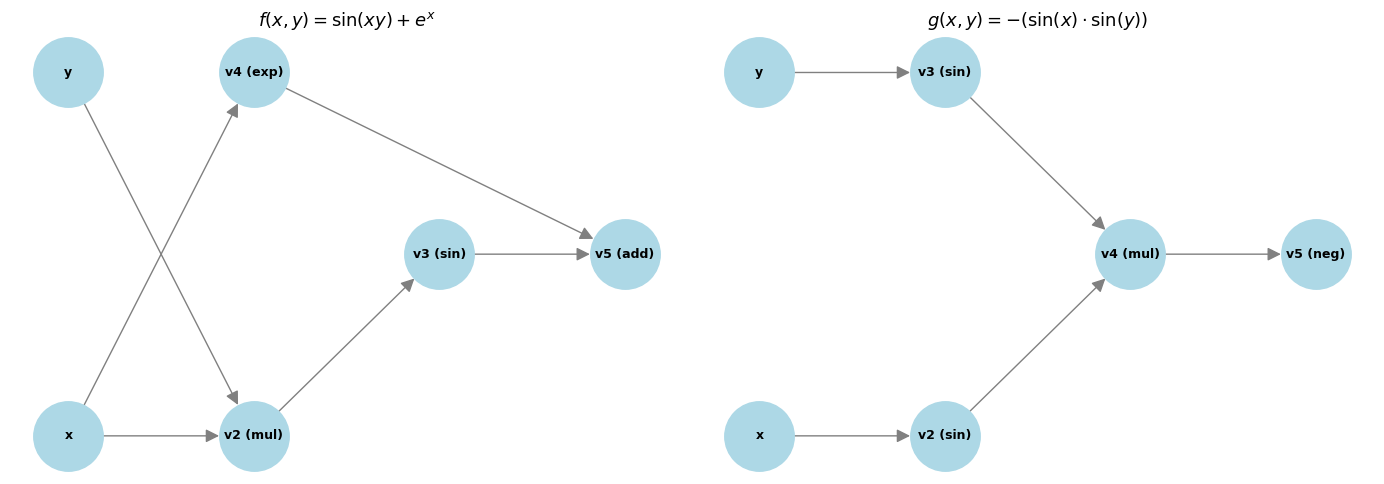

In [49]:
# Trace f to fill the tape
grad(f)(0.5, 3.0)
G_f = tape_to_graph(_tape, ["x", "y"])
print(f"Graph of f: {G_f.number_of_nodes()} nodes, {G_f.number_of_edges()} edges")

# Trace g to fill the tape
grad(g)(1.0, 2.0)
G_g = tape_to_graph(_tape, ["x", "y"])
print(f"Graph of g: {G_g.number_of_nodes()} nodes, {G_g.number_of_edges()} edges")

# Side-by-side visualization
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, G, title in [(axes[0], G_f, r"$f(x,y) = \sin(xy) + e^x$"),
                       (axes[1], G_g, r"$g(x,y) = -(\sin(x) \cdot \sin(y))$")]:
    labels = nx.get_node_attributes(G, 'label')
    # Disposition en couches par profondeur topologique
    for layer, nodes in enumerate(nx.topological_generations(G)):
        for node in nodes:
            G.nodes[node]["layer"] = layer
    pos = nx.multipartite_layout(G, subset_key="layer")
    nx.draw(G, pos, ax=ax, with_labels=True, labels=labels,
            node_color="lightblue", node_size=2500,
            font_size=9, font_weight="bold",
            arrowsize=20, edge_color="gray")
    ax.set_title(title, fontsize=13)

plt.tight_layout()
plt.show()

### Comparison: manual construction vs tracer

| | Manual construction (NetworkX) | Tracer (`Var` + `grad`) |
|---|---|---|
| Graph | Built by hand (`add_node`, `add_edge`) | Built automatically by the trace |
| Function | Written separately from the graph | Written once, normally |
| Modification | Redo the graph at each change | Nothing to change: the trace adapts |
| Control flow | Impossible (the graph is static) | Loops and conditions handled naturally |

### The import trick

The tracer mechanism explains why, in JAX, we write `import jax.numpy as jnp` instead of `import numpy as np`. The functions `jnp.sin`, `jnp.exp`, etc. know how to handle JAX tracers, so the user code remains unchanged.

---
## Part 6: The namespace approach

The previous parts used **operator overloading**: `sin` and `exp` were methods of `Var`, and the function to differentiate was written as `(x * y).sin() + x.exp()`. This syntax is explicit, but it doesn't look like typical NumPy code.

Real AD libraries (autograd, JAX) adopt a different strategy: they provide a **namespace** that reimplements NumPy functions. When the argument is a tracer, the function records the operation on the tape; when it's an ordinary number, it delegates to the standard library. The user only needs to change the import line.

```python
import autograd.numpy as anp   # autograd
import jax.numpy as jnp        # JAX
```

Construisons un tel espace de noms pour notre traceur.

In [50]:
class tracer_numpy:
    """Namespace that reimplements math functions for tracers.

    Simplified analogue of autograd.numpy or jax.numpy.
    If the argument is a Var, the operation is recorded on the tape.
    Otherwise, the standard function is called.
    """

    @staticmethod
    def sin(x):
        if isinstance(x, Var):
            return x._record(sin_vjp, (x.data,), [x], math.sin(x.data))
        return math.sin(x)

    @staticmethod
    def exp(x):
        if isinstance(x, Var):
            return x._record(exp_vjp, (x.data,), [x], math.exp(x.data))
        return math.exp(x)

    @staticmethod
    def cos(x):
        # Useful for analytical verification, no VJP needed here
        if isinstance(x, Var):
            raise NotImplementedError("cos is not yet traced")
        return math.cos(x)

# Alias court, comme jnp pour jax.numpy
tnp = tracer_numpy()

The `Var` class keeps its arithmetic operators (`+`, `*`, `-`) since these are intercepted by Python through special methods (`__add__`, `__mul__`, etc.). However, functions like `sin` and `exp` go through the namespace. The function to differentiate is now written like ordinary NumPy code:

In [51]:
# With operator overloading (parts 2-4):
#   def f(x, y): return (x * y).sin() + x.exp()
#
# With the namespace:
def f_ns(x, y):
    return tnp.sin(x * y) + tnp.exp(x)

def g_ns(x, y):
    return -(tnp.sin(x) * tnp.sin(y))

# Verification: gradients are identical
df_dx, df_dy = grad(f_ns)(0.5, 3.0)
df_dx_exact = 3.0 * math.cos(0.5 * 3.0) + math.exp(0.5)
df_dy_exact = 0.5 * math.cos(0.5 * 3.0)

print("--- f(x,y) = sin(xy) + exp(x), via namespace ---")
print(f"∂f/∂x = {df_dx:.6f}  (exact: {df_dx_exact:.6f})")
print(f"∂f/∂y = {df_dy:.6f}  (exact: {df_dy_exact:.6f})")
assert np.allclose(df_dx, df_dx_exact) and np.allclose(df_dy, df_dy_exact)

dg_dx, dg_dy = grad(g_ns)(1.0, 2.0)
dg_dx_exact = -math.cos(1.0) * math.sin(2.0)
dg_dy_exact = -math.sin(1.0) * math.cos(2.0)

print("\n--- g(x,y) = -(sin(x)·sin(y)), via namespace ---")
print(f"∂g/∂x = {dg_dx:.6f}  (exact: {dg_dx_exact:.6f})")
print(f"∂g/∂y = {dg_dy:.6f}  (exact: {dg_dy_exact:.6f})")
assert np.allclose(dg_dx, dg_dx_exact) and np.allclose(dg_dy, dg_dy_exact)
print("\nAll gradients match.")

--- f(x,y) = sin(xy) + exp(x), via namespace ---
∂f/∂x = 1.860933  (exact: 1.860933)
∂f/∂y = 0.035369  (exact: 0.035369)

--- g(x,y) = -(sin(x)·sin(y)), via namespace ---
∂g/∂x = -0.491295  (exact: -0.491295)
∂g/∂y = 0.350175  (exact: 0.350175)

All gradients match.


The tape, the `grad` function, and the VJP rules are exactly the same in both approaches. Only the **interception mechanism** changes:

| | Operator overloading | Namespace |
|---|---|---|
| Interception | Python special methods (`__add__`, `sin`) | Functions in a module (`tnp.sin`) |
| Syntax | `(x * y).sin()` | `tnp.sin(x * y)` |
| Adding a primitive | Add a method to `Var` | Add a function to `tracer_numpy` |
| Looks like NumPy | No | Yes |
| Libraries | PyTorch (partially) | autograd, JAX |

In practice, both mechanisms coexist. PyTorch uses operator overloading for `+`, `*`, etc., and namespace functions like `torch.sin`, `torch.exp`, etc. JAX does the same with `jax.numpy`.

---
## Bonus

### Exercise 4 ★: Subtraction by composition

Add `__sub__` and `__rsub__` to the `Var` class **without defining a new VJP rule**. Reuse `__add__` and `__neg__` (since $a - b = a + (-b)$).

Test on $h(x,y) = x - y$ with values $x = 3$, $y = 1$.

In [52]:
# ============================================
# Exercise 4 ★ (bonus): Add __sub__ and __rsub__
#
# Reminder: a - b = a + (-b) and negation is already implemented.
# Remember to handle the case where other is not a Var.
# ============================================

# Uncomment and complete:
def _sub(self, other):
    other = other if isinstance(other, Var) else Var(other)
    return self + (-other)

def _rsub(self, other):
    other = other if isinstance(other, Var) else Var(other)
    return other + (-self)

Var.__sub__ = _sub
Var.__rsub__ = _rsub

# Test (uncomment after completing):
dh_dx, dh_dy = grad(lambda x, y: x - y)(3.0, 1.0)
print(f"∂h/∂x = {dh_dx} (expected: 1.0)")
print(f"∂h/∂y = {dh_dy} (expected: -1.0)")

∂h/∂x = 1.0 (expected: 1.0)
∂h/∂y = -1.0 (expected: -1.0)


<details>
<summary><b>Solution Exercise 4</b> (click to show)</summary>

```python
def _sub(self, other):
    other = other if isinstance(other, Var) else Var(other)
    return self + (-other)

def _rsub(self, other):
    other = other if isinstance(other, Var) else Var(other)
    return other + (-self)

Var.__sub__ = _sub
Var.__rsub__ = _rsub

dh_dx, dh_dy = grad(lambda x, y: x - y)(3.0, 1.0)
print(f"∂h/∂x = {dh_dx} (expected: 1.0)")
print(f"∂h/∂y = {dh_dy} (expected: -1.0)")
```

Subtraction doesn't need a new VJP rule: it decomposes into a negation followed by an addition, and backpropagation traverses both operations correctly.
</details>